### Imports needed for the script

In [1]:
import pandas as pd
import numpy as np
from sklearn import tree
from deap import gp
from gp.deap_gp import setup_pset
from gp.gp_generalise import infer_output
import matplotlib.pyplot as plt
from gp import deap_gp

### All functions used in the script are gathered here. Needs to be run before you can start doing evaluations.

In [ ]:
#Functions to generate input samples, functions, output, and to infer with GP

def create_input_samples(numInputParameters, parameterRange=(0, 100), distinctInputSet=None, tableLength=10, random_seed=42):
    np.random.seed(random_seed)
    if distinctInputSet:
        df = pd.DataFrame()
        for i in range(numInputParameters):
            df[f'i{i}']=np.random.choice(distinctInputSet, size=tableLength)
            reg = np.zeros_like(df[f'i{i}'])
            reg[0] = np.random.choice(distinctInputSet)
            reg[1:] = df[f'i{i}'][:-1].values
            df[f'r{i}'] = reg 
    else:
        df = pd.DataFrame()
        for i in range(numInputParameters):
            df[f'i{i}']=np.random.randint(*parameterRange, size=tableLength)
            reg = np.zeros_like(df[f'i{i}'])
            reg[0] = np.random.randint(*parameterRange)
            reg[1:] = df[f'i{i}'][:-1].values
            df[f'r{i}'] = reg
    df = df[[c for c in df.columns if c.startswith('i')] + [c for c in df.columns if c.startswith('r')]]
    return df

def get_true_function_output(trueFunction, df):
    # build a pset with a dummy output column so arg names are renamed to df columns
    # add an output register to the dataframe 
    regs = df.columns.tolist()
    regs = [r for r in regs if r.startswith('r')]
    regsnums = [int(r[1:]) for r in regs]
    max_reg_num = max(regsnums) if regsnums else -1
    df[f'r{max_reg_num + 1}'] = np.zeros((len(df),), dtype=int)
    #add randomvalue to the first row of the output register to ensure it's not all zeros if the true function uses it
    # df.at[0, f'r{max_reg_num + 1}'] = np.random.randint(1,100)

    # compile the true function and apply it to the dataframe to get the output column

    df['o'] = np.zeros_like(df[f'r{max_reg_num + 1}'])
    pset = deap_gp.setup_pset(df)
    tree = gp.PrimitiveTree.from_string(trueFunction, pset)
    trueFunctionCompiled = gp.compile(tree, pset)
    if f'r{max_reg_num + 1}' not in trueFunction:
        df['o'] = df.drop(columns='o').apply(lambda row: trueFunctionCompiled(**row.to_dict()), axis=1)
        df.loc[1:, f'r{max_reg_num + 1}'] = df['o'][:-1].values
    else:
        for idx in df.index:
            if idx > 0:
                df.at[idx, f'r{max_reg_num + 1}'] = df.at[idx-1, 'o']
            row = df.loc[idx, df.drop(columns='o').columns]   
            df.at[idx, 'o'] = trueFunctionCompiled(**row.to_dict())
    
    # reorder columns to have inputs, then registers, then output
    df = df[[c for c in df.columns if c.startswith('i')] + [c for c in df.columns if c.startswith('r')] + ['o']]
    return df

def setFunction(parameters, complexity, constantProb=0.3, maxConstant=10, random_seed=42, original_output_register=None):
    np.random.seed(random_seed)
    #Added in main code instead of here to avoid duplication 
    # regs = parameters.copy()
    # regs = [r for r in regs if r.startswith('r')]
    # regsnums = [int(r[1:]) for r in regs]
    # max_reg_num = max(regsnums) if regsnums else -1
    # parameters.append(f'r{max_reg_num + 1}') # add output register as a parameter for the function to use
    ops = ['add', 'sub', 'mul']
    constantProb = 1/(len(parameters)+1)
    u = np.random.random_sample()
    if u < constantProb:
        param1 = str(np.random.randint(1, maxConstant + 1))
    else:
        param1 = np.random.choice(parameters)
    # if the output register is used as a parameter, only allow add and sub to avoid infinite growth
    # remove this if you want to allow mul with the output register, but be aware it can lead to very large values and overflow
    if param1 == original_output_register:
        ops = ['add', 'sub']   
    if complexity <= 1:
        if complexity == 0:
            ops = ['add', 'sub']
        else:
            parameters = [p for p in parameters if p != param1]
        param2 = np.random.choice(parameters)
        op = np.random.choice(ops)
        # if the output register is used as a parameter, only allow add and sub to avoid infinite growth
        # remove this if you want to allow mul with the output register, but be aware it can lead to very large values and overflow
        if param2 == original_output_register:
            op = np.random.choice(['add', 'sub']) 
        return op + "(" + param1 + "," + param2 + ")"
    else:
        func = setFunction(parameters, complexity-1, constantProb, maxConstant, original_output_register=original_output_register)
        op = np.random.choice(ops)
        return op + "(" + param1 + "," + func + ")"

def setFunctionLinear(parameters, depth, maxCoeff=10, random_seed=42):
    ops = ['add', 'sub', 'mul']
    expr = ""
    np.random.seed(random_seed)
    while depth > 0:
        op = np.random.choice(ops)
        param = np.random.choice(parameters)
        if op == 'mul':
            coeff = np.random.randint(1, maxCoeff + 1)
            plusMinus = np.random.choice(['', '-'])
            newexpr = plusMinus + str(coeff) + "*" + param
        else:
            param1 = np.random.choice(parameters)
            param2 = np.random.choice(parameters)
            newexpr = param1 + op + param2
            depth -= 1
        if expr == "":
            expr = newexpr
        else:
            expr = expr + "+" + newexpr
    return expr

def infer_w_gp(df, ngen=100, random_seed=42):
    tmp = df.drop(columns=['o']).copy()
    pset = deap_gp.setup_pset(df)
    inferredFuncStr = infer_output(df, ngen=ngen, random_seed=random_seed)
    tree = gp.PrimitiveTree.from_string(inferredFuncStr, pset)
    inferredFunctionCompiled = gp.compile(tree, pset)
    df['inferred'] = tmp.apply(lambda row: inferredFunctionCompiled(**row.to_dict()), axis=1)
    return inferredFuncStr, df

### Here is where you set the parameters for evaluation. 

In [ ]:
# Parameters for data generation and inference
sampledFuncs = 3 # number of different functions to sample and test for each complexity level and number of input parameters
max_table_length = 60 # maximum length of the input-output table to generate for each function
tableLength = np.arange(20, max_table_length+1, 20) # lengths of the input-output tables to generate for each function
numGenerations = [100, 200, 300] # number of generations to run the GP inference for each function and table length
seedsForTable = np.arange(sampledFuncs) # seeds for sampling the functions and generating the input-output tables, one for each function to sample and test
seedsForGP = [0, 1, 2, 3, 4] # seeds for running the GP inference
complexities = [1, 2, 3] # complexity levels for the true functions to generate and test
linear = False # If you want to only generate linear functions (i.e. no multiplication), set this to True
numInputParameters = [1, 2, 3] # numbers of input parameters for the true functions to generate and test, one register per input parameter plus one output register will also be added as a parameter for the true functions to use
parameterRange = (0, 10) # range for the input parameters when sampling the true functions and generating the input-output tables
maxConstant = 10 # maximum constant value to use when sampling the true functions


### Here is where the inference happens, the GP tool is run for all set up combinations above
### Be aware that by increasing number of seeds for GP, functions, generations or table lengths the time for running this increases quickly.


In [ ]:
# DataFrame to store results of inferred functions for each complexity, tableLength, numGenerations combination
inferredFuncs = pd.DataFrame(columns=['complexity', 'trueFunction', 'seed', 'tableLength', 'numGenerations', 'inferredFunc', 'numInputParameters'])
dfs = {}

totalRuns = len(complexities) * sampledFuncs * len(seedsForGP) * len(tableLength) * len(numGenerations) * len(numInputParameters)
currentRun = 0
for numParams in numInputParameters:
    for complexity in complexities:
        for s in seedsForTable:
            #Create input samples
            complete_df = create_input_samples(numInputParameters=numParams, parameterRange=parameterRange, tableLength=max_table_length, random_seed=s)
            #Define true function and output samples
            parameters = [d for d in complete_df.columns]
            regs = parameters.copy()
            regs = [r for r in regs if r.startswith('r')]
            regsnums = [int(r[1:]) for r in regs]
            max_reg_num = max(regsnums) if regsnums else -1
            out_put_register = f'r{max_reg_num + 1}'
            parameters.append(f'r{max_reg_num + 1}') # add output register as a parameter for the function to use
            if linear:
                trueFunction = setFunctionLinear(parameters, complexity, random_seed=s)
            else:
                trueFunction = setFunction(parameters, complexity, random_seed=s, original_output_register=out_put_register)
            print(f"True function: {trueFunction}")
            complete_df = get_true_function_output(trueFunction, complete_df)
            dfs[trueFunction] = complete_df
            complete_df['inferred'] = np.zeros(len(complete_df))
            for seed in seedsForGP:
                for i, t in enumerate(tableLength):
                    df = complete_df.head(t).copy()
                    for j, g in enumerate(numGenerations):
                        func, df = infer_w_gp(df.drop(columns=['inferred']), ngen=g, random_seed=seed)
                        inferredFuncs = pd.concat([inferredFuncs, pd.DataFrame({'complexity': [complexity], 'trueFunction': [trueFunction], 'seed': [seed], 'tableLength': [t], 'numGenerations': [g], 'inferredFunc': [func], 'numInputParameters': [numParams]})], ignore_index=True)
                        print(f"Completed run {currentRun + 1} of {totalRuns}")
                        currentRun += 1
            

True function: sub(r0,i0)
inferred output function:  add(r0, mul(-1, i0))
Completed run 1 of 1215
inferred output function:  add(r0, mul(-1, i0))
Completed run 2 of 1215
inferred output function:  add(r0, mul(-1, i0))
Completed run 3 of 1215
inferred output function:  add(r0, mul(-1, i0))
Completed run 4 of 1215
inferred output function:  add(r0, mul(-1, i0))
Completed run 5 of 1215
inferred output function:  add(r0, mul(-1, i0))
Completed run 6 of 1215
inferred output function:  add(r0, mul(-1, i0))
Completed run 7 of 1215
inferred output function:  add(r0, mul(-1, i0))
Completed run 8 of 1215
inferred output function:  add(r0, mul(-1, i0))
Completed run 9 of 1215
inferred output function:  add(r0, mul(-1, i0))
Completed run 10 of 1215
inferred output function:  add(r0, mul(-1, i0))
Completed run 11 of 1215
inferred output function:  add(r0, mul(-1, i0))
Completed run 12 of 1215
inferred output function:  add(r0, mul(-1, i0))
Completed run 13 of 1215
inferred output function:  add(r0,

### Run the cell below to have a safe copy of the data produced above so if you make changes you dont have to rerun the time consuming inference

In [5]:
copyFuncs = inferredFuncs.copy()
copyTables = dfs.copy()

### uncomment and run the cell below to restore from the copy made above.

In [ ]:
# dfs = copyTables
# inferredFuncs = copyFuncs

### The cell below creates does the actual evaluation by:
1. Gathering the kinds of errors made for each inference, for each true function. 
2. Calculate the precentage of each error per true function 
3. Averages this result over the complexity, table length, number of generations in the GP and number of parameters

In [16]:
# Analyze errors and correlations to inputs of inferred functions
dfsForParams = {}
for numParams in numInputParameters:
    forNumParams = inferredFuncs[inferredFuncs['numInputParameters'] == numParams]
    errorAnalysis = pd.DataFrame(columns=['complexity', 'tableLength', 'numGenerations', 'AccurateInferenceRate', 'ConstantErrorRate', 'OneHighCorrelationRate', 'MoreHighCorrelationsRate'])
    for complexity in complexities:
        for t in tableLength:
            for g in numGenerations:
                subset = forNumParams[(forNumParams['complexity'] == complexity) & (forNumParams['tableLength'] == t) & (forNumParams['numGenerations'] == g )]
                meanAccurateInferenceCount = 0
                meanConstantErrorCount = 0
                meanOneHighCorrelationCount = 0
                meanMoreHighCorrelationCount = 0
                for trueFunc in subset['trueFunction'].unique():
                    subForFunc = subset[subset['trueFunction'] == trueFunc]
                    accurateInferenceCount = 0
                    constantErrorCount = 0
                    oneHighCorrelationCount = 0
                    twoHighCorrelationsCount = 0
                    moreHighCorrelationsCount = 0
                    trueOutput = dfs[trueFunc]['o'].head(t)
                    for index, row in subForFunc.iterrows():
                        trueFunc = row['trueFunction']
                        inferredFunc = row['inferredFunc']
                        df = dfs[trueFunc].drop(columns=['inferred']).head(t).copy()
                        pset = setup_pset(df)
                        #treeTrue = gp.PrimitiveTree.from_string(trueFunc, pset)
                        treeInferred = gp.PrimitiveTree.from_string(inferredFunc, pset)
                        #funcTrueCompiled = gp.compile(treeTrue, pset)
                        funcInferredCompiled = gp.compile(treeInferred, pset)
                        #df['trueOutput'] = df.drop(columns=['o']).apply(lambda row: funcTrueCompiled(**row.to_dict()), axis=1)
                        df['inferredOutput'] = df.drop(columns=['o']).apply(lambda row: funcInferredCompiled(**row.to_dict()), axis=1)
                        error = trueOutput - df['inferredOutput']
                        if np.all(error == 0):
                            accurateInferenceCount += 1
                        elif np.all(error == error.iloc[0]):
                            constantErrorCount += 1
                        else:
                            correlations = []
                            for col in df.columns:
                                if col.startswith('i') or col.startswith('r'):
                                    if np.std(df[col]) == 0:
                                        # if the inferred function is constant, the correlation is not defined, so we set it to 0 to avoid NaN values
                                        # this is ok since if the infered function is constant but not correct the issue 
                                        # comes from other inputs.
                                        corr = 0
                                    else:
                                        corr = np.corrcoef(df[col], error)[0,1]
                                    correlations.append(abs(corr))
                            threshold = max(correlations)*2/3
                            countHighCorrelation = sum(1 for c in correlations if c >= threshold)
                            if countHighCorrelation == 1:
                                oneHighCorrelationCount += 1
                            elif countHighCorrelation >= 2:
                                moreHighCorrelationsCount += 1
                            else:
                                pass
                    totalCount = len(subForFunc)
                    accurateInferenceRate = accurateInferenceCount / totalCount if totalCount > 0 else np.nan
                    constantErrorRate = constantErrorCount / totalCount if totalCount > 0 else np.nan
                    oneHighCorrelationRate = oneHighCorrelationCount / totalCount if totalCount > 0 else np.nan
                    moreHighCorrelationsRate = moreHighCorrelationsCount / totalCount if totalCount > 0 else np.nan
            
                    meanAccurateInferenceCount += accurateInferenceRate
                    meanConstantErrorCount += constantErrorRate
                    meanOneHighCorrelationCount += oneHighCorrelationRate
                    meanMoreHighCorrelationCount += moreHighCorrelationsRate
                sampledFuncCount = len(subset['trueFunction'].unique())
                meanAccurateInferenceRate = meanAccurateInferenceCount / sampledFuncCount if sampledFuncCount > 0 else np.nan
                meanConstantErrorRate = meanConstantErrorCount / sampledFuncCount if sampledFuncCount > 0 else np.nan
                meanOneHighCorrelationRate = meanOneHighCorrelationCount / sampledFuncCount if sampledFuncCount > 0 else np.nan
                meanMoreHighCorrelationRate = meanMoreHighCorrelationCount / sampledFuncCount if sampledFuncCount > 0 else np.nan
                errorAnalysis = pd.concat([errorAnalysis, pd.DataFrame({'complexity': [complexity], 'tableLength': [t], 'numGenerations': [g], 'Accurate Inference': [meanAccurateInferenceRate], 'Constant Error': [meanConstantErrorRate], 'One High Correlation': [meanOneHighCorrelationRate], 'Two or More High Correlations': [meanMoreHighCorrelationRate]})], ignore_index=True)
    dfsForParams[numParams] = errorAnalysis


### This cell produces the plots of the results gathered above

/Users/petreanorgren/anaconda3/envs/TER_legacy/lib/python3.10/site-packages/pandas/core/indexes/base.py:6982: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  return Index(sequences[0], name=names)
/Users/petreanorgren/anaconda3/envs/TER_legacy/lib/python3.10/site-packages/pandas/core/indexes/base.py:6982: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  return Index(sequences[0], name=names)
/Users/petreanorgren/anaconda3/envs/TER_legacy/lib/python3.10/site-packages/pandas/core/indexes/base.py:6982: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  return Index(sequences[0], name=names)
/Users/petreanorgren/anaconda3/envs/TER_legacy/lib/python3.10/site-packages/pandas/core/indexes/b

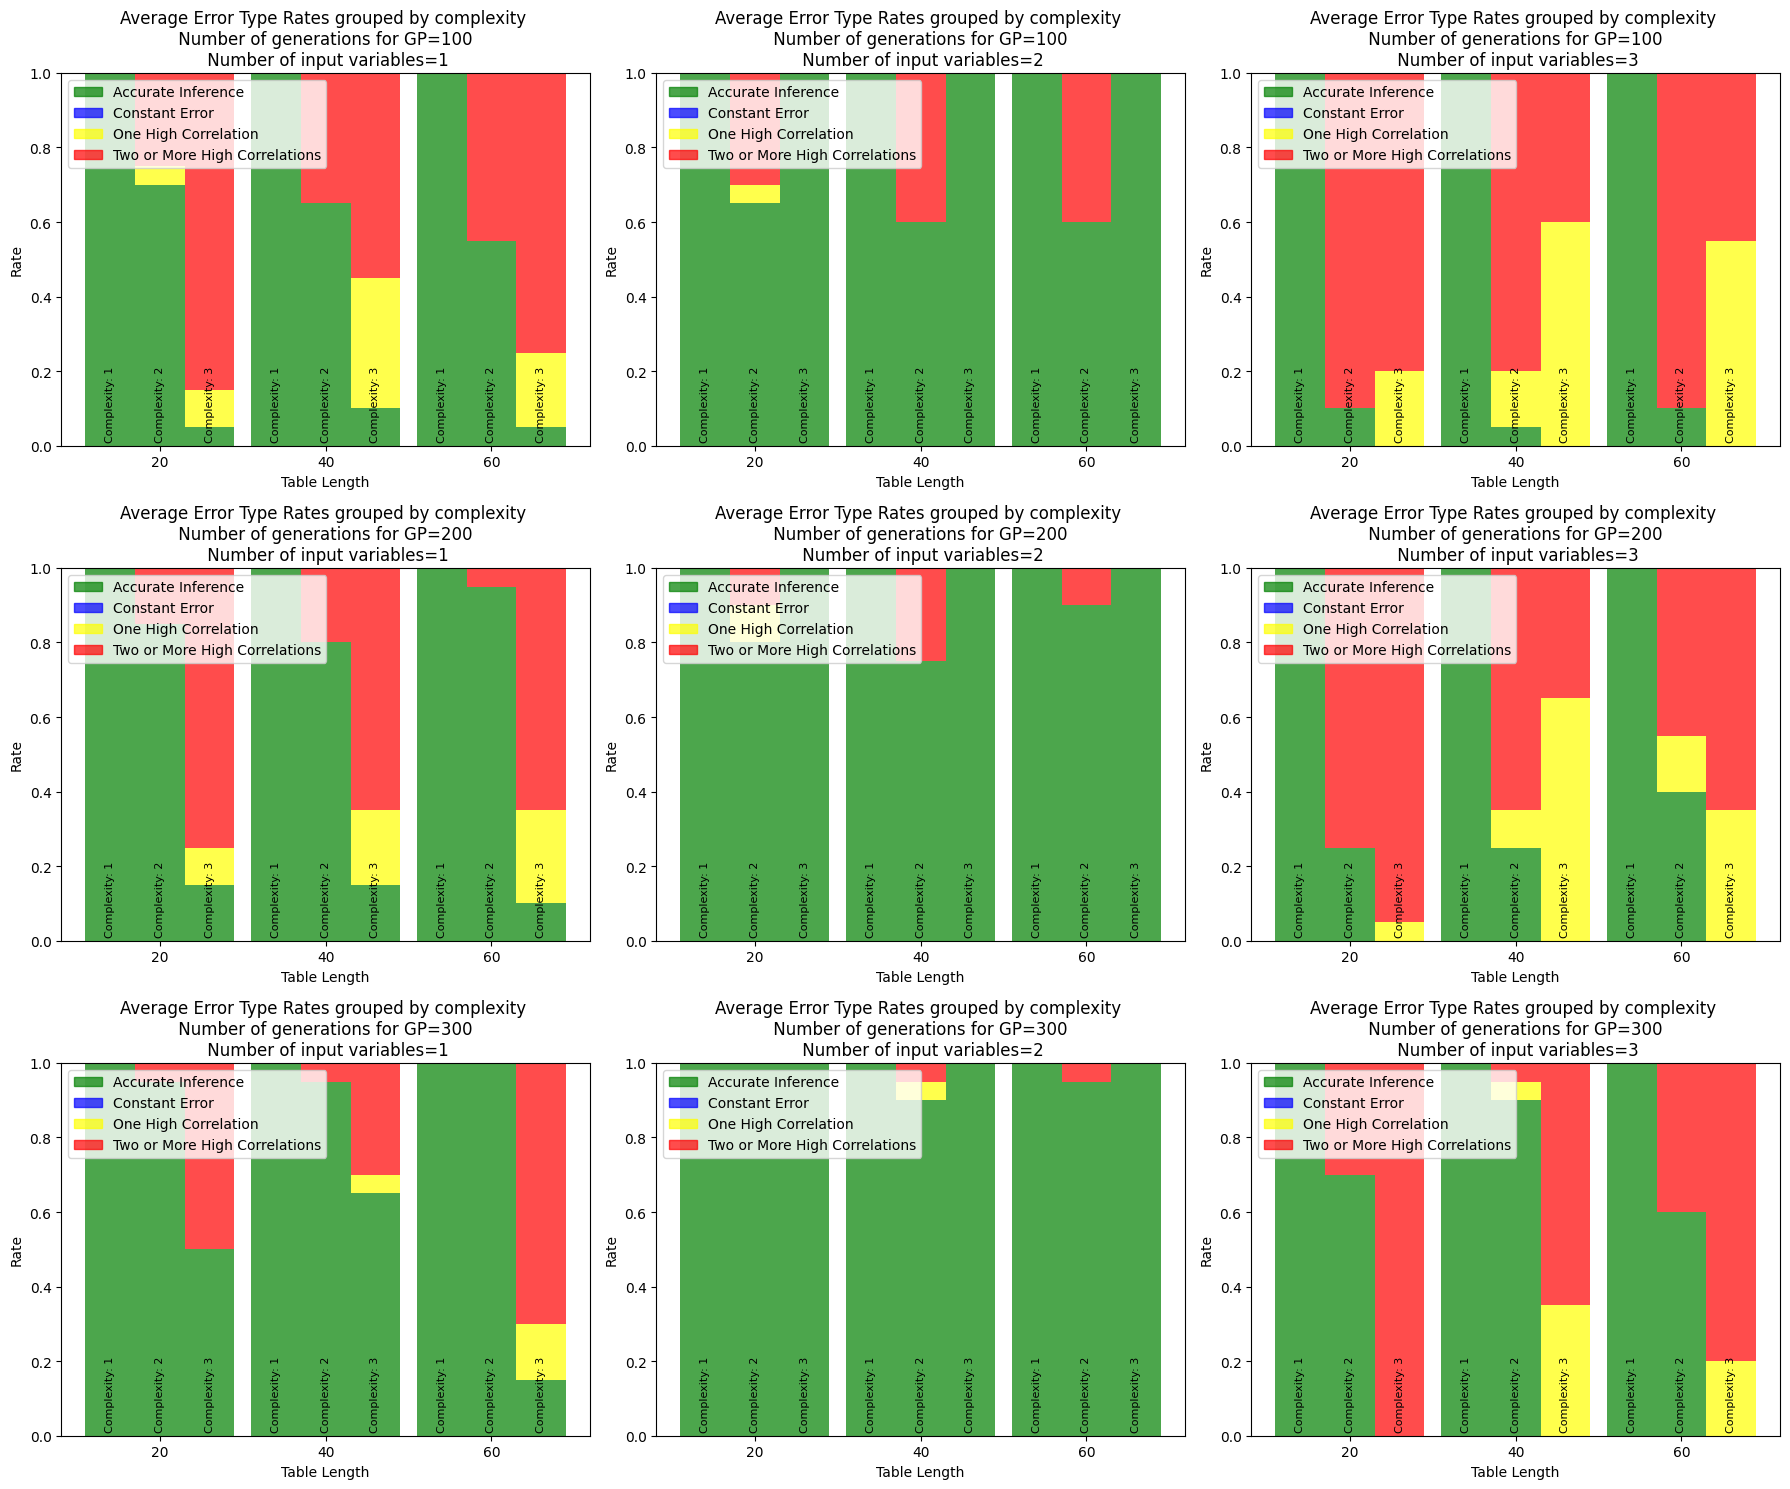

In [17]:
# One stacked bar chart for each numGenerations: grouped by tableLength, bars grouped per complexity
errorTypes = ['Accurate Inference', 'Constant Error', 'One High Correlation', 'Two or More High Correlations']
colors = ['green', 'blue', 'yellow', 'red']

fig, axes = plt.subplots(len(numGenerations), len(numInputParameters), figsize=(6*len(numInputParameters), 5*len(numGenerations)))
# normalize axes to a 2D array for consistent indexing
axes_arr = np.array(axes)
if axes_arr.ndim == 0:
    axes_arr = axes_arr.reshape((1,1))
elif axes_arr.ndim == 1:
    if len(numGenerations) == 1:
        axes_arr = axes_arr.reshape((1, -1))
    else:
        axes_arr = axes_arr.reshape((-1, 1))

for i, numParams in enumerate(numInputParameters):
    errorAnalysis = dfsForParams[numParams]
    for j, g in enumerate(numGenerations):
        ax = axes_arr[j, i]
        subset_g = errorAnalysis[errorAnalysis['numGenerations'] == g]
        group_keys = subset_g[['tableLength']].drop_duplicates().sort_values(['tableLength'])
        labels = [f"{int(r['tableLength'])}" for _, r in group_keys.iterrows()]
        n_groups = len(labels)
        n_complexities = len(complexities)
        bar_width = 0.15
        group_spacing = 0.05
        group_width = n_complexities * bar_width + group_spacing
        x_groups = np.arange(n_groups) * group_width

        for ci, comp in enumerate(complexities):
            bottoms = np.zeros(n_groups)
            comp_subset = subset_g[subset_g['complexity'] == comp].set_index(['tableLength'])
            # ensure index dtype matches the keys
            try:
                comp_subset.index = comp_subset.index.astype(int)
            except Exception:
                pass
            positions = x_groups + (ci - (n_complexities - 1) / 2.0) * bar_width
            for ei, et in enumerate(errorTypes):
                vals = []
                for _, r in group_keys.iterrows():
                    key = int(r['tableLength'])
                    if key in comp_subset.index:
                        v = comp_subset.loc[key, et]
                        try:
                            vals.append(float(v))
                        except Exception:
                            vals.append(0.0)
                    else:
                        vals.append(0.0)
                ax.bar(positions, vals, bar_width, bottom=bottoms, color=colors[ei], label=et if ci == 0 else "", alpha=0.7)
                bottoms += np.array(vals)

            max_height = np.max(bottoms) if len(bottoms) > 0 else 0.0
            for pos, total in zip(positions, bottoms):
                ax.text(pos, 0.01, f'Complexity: {comp}', ha='center', va='bottom', fontsize=8, rotation=90)

        ax.set_xticks(x_groups)
        ax.set_xticklabels(labels)
        ax.set_xlabel('Table Length')
        ax.set_ylabel('Rate')
        ax.set_title(f'Average Error Type Rates grouped by complexity \n Number of generations for GP={g} \n Number of input variables={numParams}')
        handles = [plt.Rectangle((0,0),1,1, color=c, alpha=0.7) for c in colors]
        ax.legend(handles, errorTypes, loc='upper left')

plt.tight_layout()
plt.show()

### The code from this point on is used to look at correlations between true functions and errors made on puropse. 
### In the following cell the set up for the input table generation is set, i.e number of inputparameters, table length, random seed for generation, parameter range.

In [61]:
numInputParameters = 2
parameterRange = (0, 100)
seed = 42
max_table_length = 100

testdf = create_input_samples(numInputParameters=numInputParameters, parameterRange=parameterRange, tableLength=max_table_length, random_seed=seed)

print(testdf.columns)

Index(['i0', 'i1', 'r0', 'r1'], dtype='object')


### In this cell you set the true function and the functions with intentional errors.

In [62]:

'''Set your true function here: '''
trueFunction = 'add(mul(i0, 2), i1)'
#Output of the true function on the input samples is added as a column to the dataframe along with its register column
testdf = get_true_function_output(trueFunction, testdf)


''' Define here the faulty functions as a dict with the key being a description of the error and the value being the function string.'''
fakeFunctions = {}
# offByConst = f'add({trueFunction}, 5)'
# fakeFunctions['off by constant term'] = offByConst #off by a constant
# offByScaleInOneVar = trueFunction.replace('2', '3')
# fakeFunctions['off by scale in one variable'] = offByScaleInOneVar #off by a scale in one variable
# fakeFunctions['off by scale in one variable and a constant term'] = f'add({offByScaleInOneVar}, 1)' #off by a scale in one variable plus a constant
# addWrongVarFunc = 'add(' + trueFunction + ', r1)'
# fakeFunctions['off by adding extra variable'] = addWrongVarFunc #off by adding a wrong variable 
# fakeFunctions['off by adding extra variable plus constant'] = f'add({addWrongVarFunc}, 2)' #off by adding a wrong variable instead of a constant plus a constant
# wrongVarFunc = trueFunction.replace('i0', 'r2')
# fakeFunctions['off by using wrong variable'] = wrongVarFunc #off by using a wrong variable instead of one in the true function
# fakeFunctions['off by using wrong variable plus constant'] = f'add({wrongVarFunc}, 1)' #off by using a wrong variable instead of one in the true function plus a constant
# fakeFunctions['Completly wrong function'] = 'add(mul(r0, r1), r2)' #completely wrong function

offByScaleInOneVar = trueFunction.replace('2', '3')
fakeFunctions['off by scale in one variable'] = offByScaleInOneVar #off by a scale in one variable
addWrongVarFunc = 'add(' + trueFunction + ', r1)'
fakeFunctions['off by adding extra variable'] = addWrongVarFunc #off by adding a wrong variable 
wrongVarFunc = trueFunction.replace('i0', 'r2')
fakeFunctions['off by using wrong variable'] = wrongVarFunc #off by using a wrong variable instead of one in the true function



# Some checks to print the true function, the fake functions, and their outputs on the input samples to verify that the setup is correct before analyzing the errors and correlations
print('Fake functions being tested: ')
for func in fakeFunctions:
    print(f" - {func}: {fakeFunctions[func]}")

trueOut = testdf['o'].values
testOuts = {}
pset = setup_pset(testdf)
i = 0
for func in fakeFunctions.values():
    if i == 0:
        print('True function: ', trueFunction)
        print(f"Inferred function: {func}")
        print(testdf.head())
    treeInferred = gp.PrimitiveTree.from_string(func, pset)
    funcCompiled = gp.compile(treeInferred, pset)
    output = testdf.drop(columns=['o']).apply(lambda row: funcCompiled(**row.to_dict()), axis=1).values
    if i == 0:
        testdf['inferred'] = output
        print(testdf.head())
        testdf = testdf.drop(columns=['inferred'])
    testOuts[func] = output
    i += 1


Fake functions being tested: 
 - off by scale in one variable: add(mul(i0, 3), i1)
 - off by adding extra variable: add(add(mul(i0, 2), i1), r1)
 - off by using wrong variable: add(mul(r2, 2), i1)
True function:  add(mul(i0, 2), i1)
Inferred function: add(mul(i0, 3), i1)
   i0  i1  r0  r1   r2    o
0  51  88  25  61    0  190
1  92  59  51  88  190  243
2  14  40  92  59  243   68
3  71  28  14  40   68  170
4  60  14  71  28  170  134
   i0  i1  r0  r1   r2    o  inferred
0  51  88  25  61    0  190       241
1  92  59  51  88  190  243       335
2  14  40  92  59  243   68        82
3  71  28  14  40   68  170       241
4  60  14  71  28  170  134       194


### The cell below displays the input and register columns correaltion to the residuals and the true function respectively. 

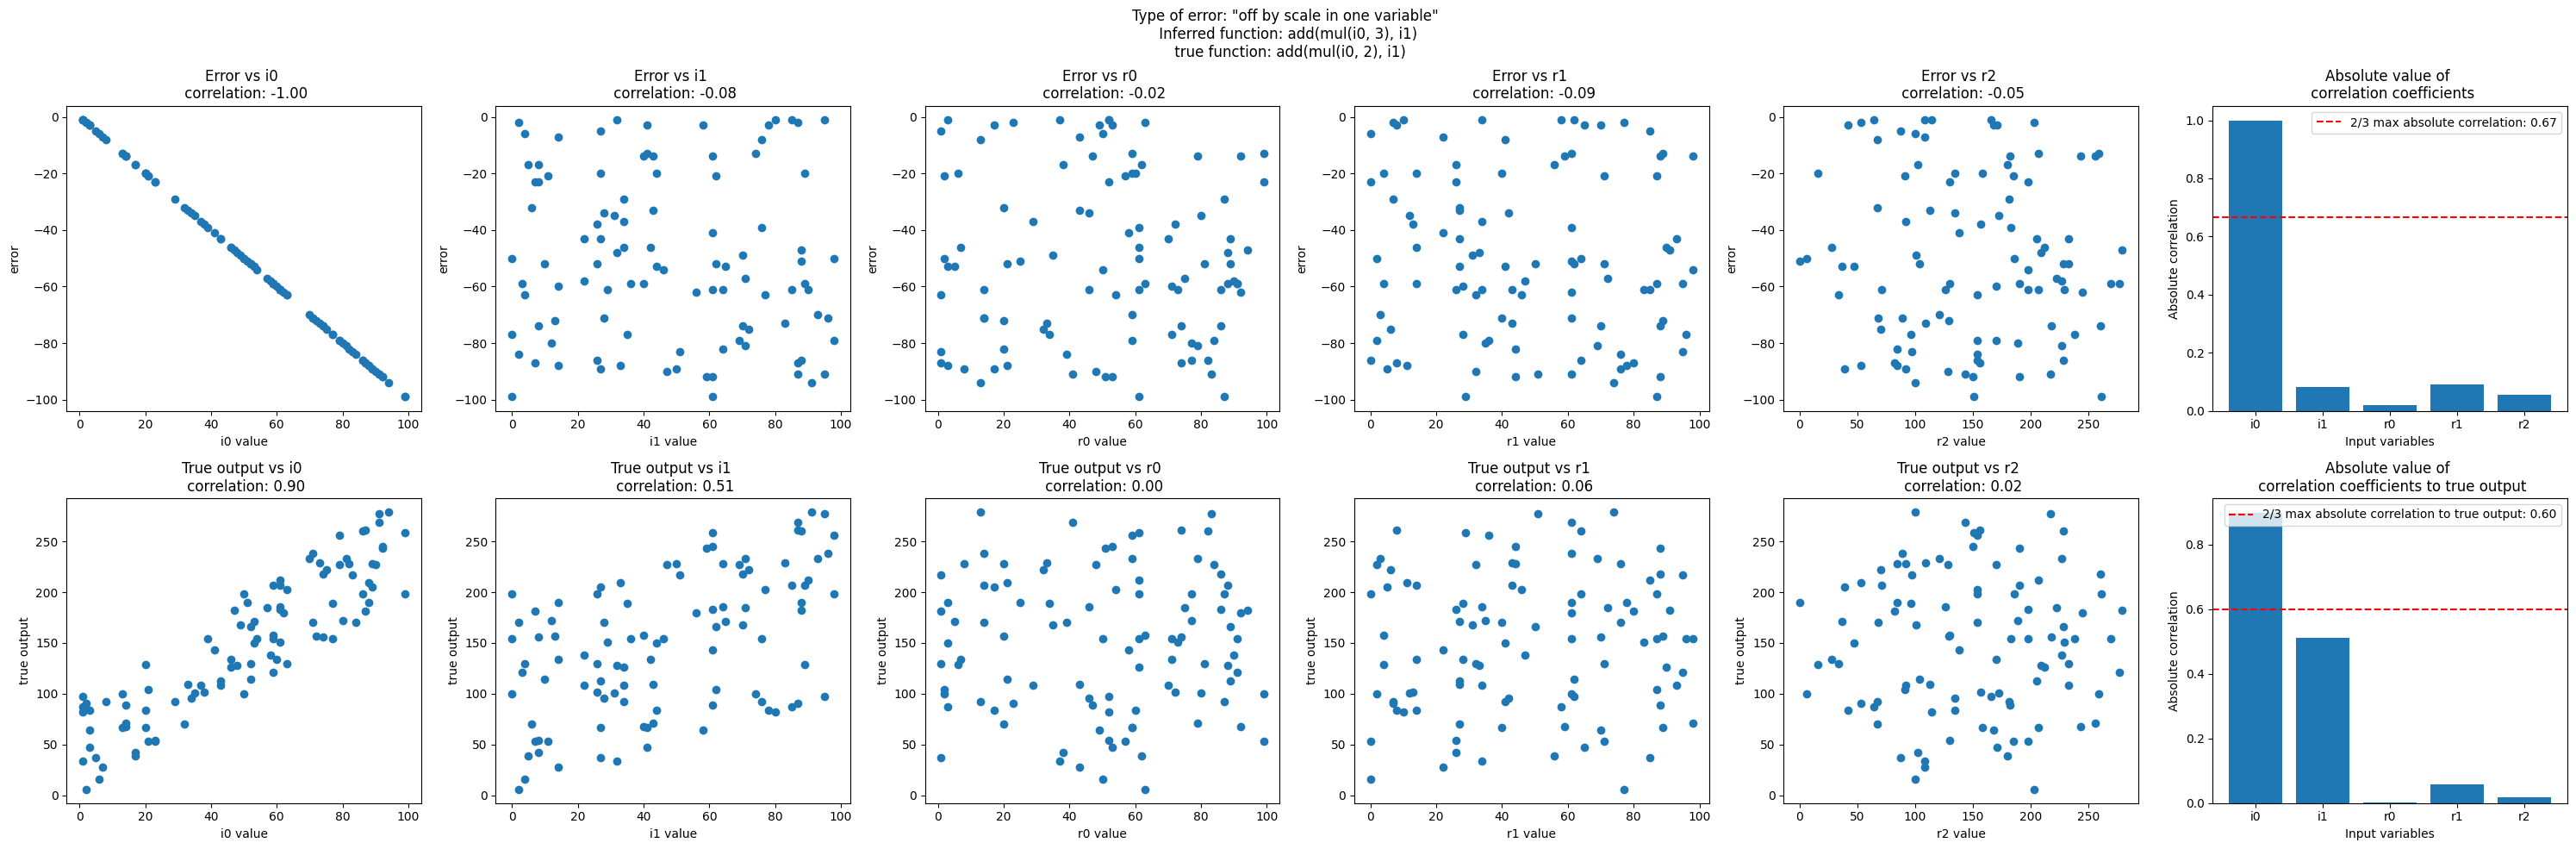

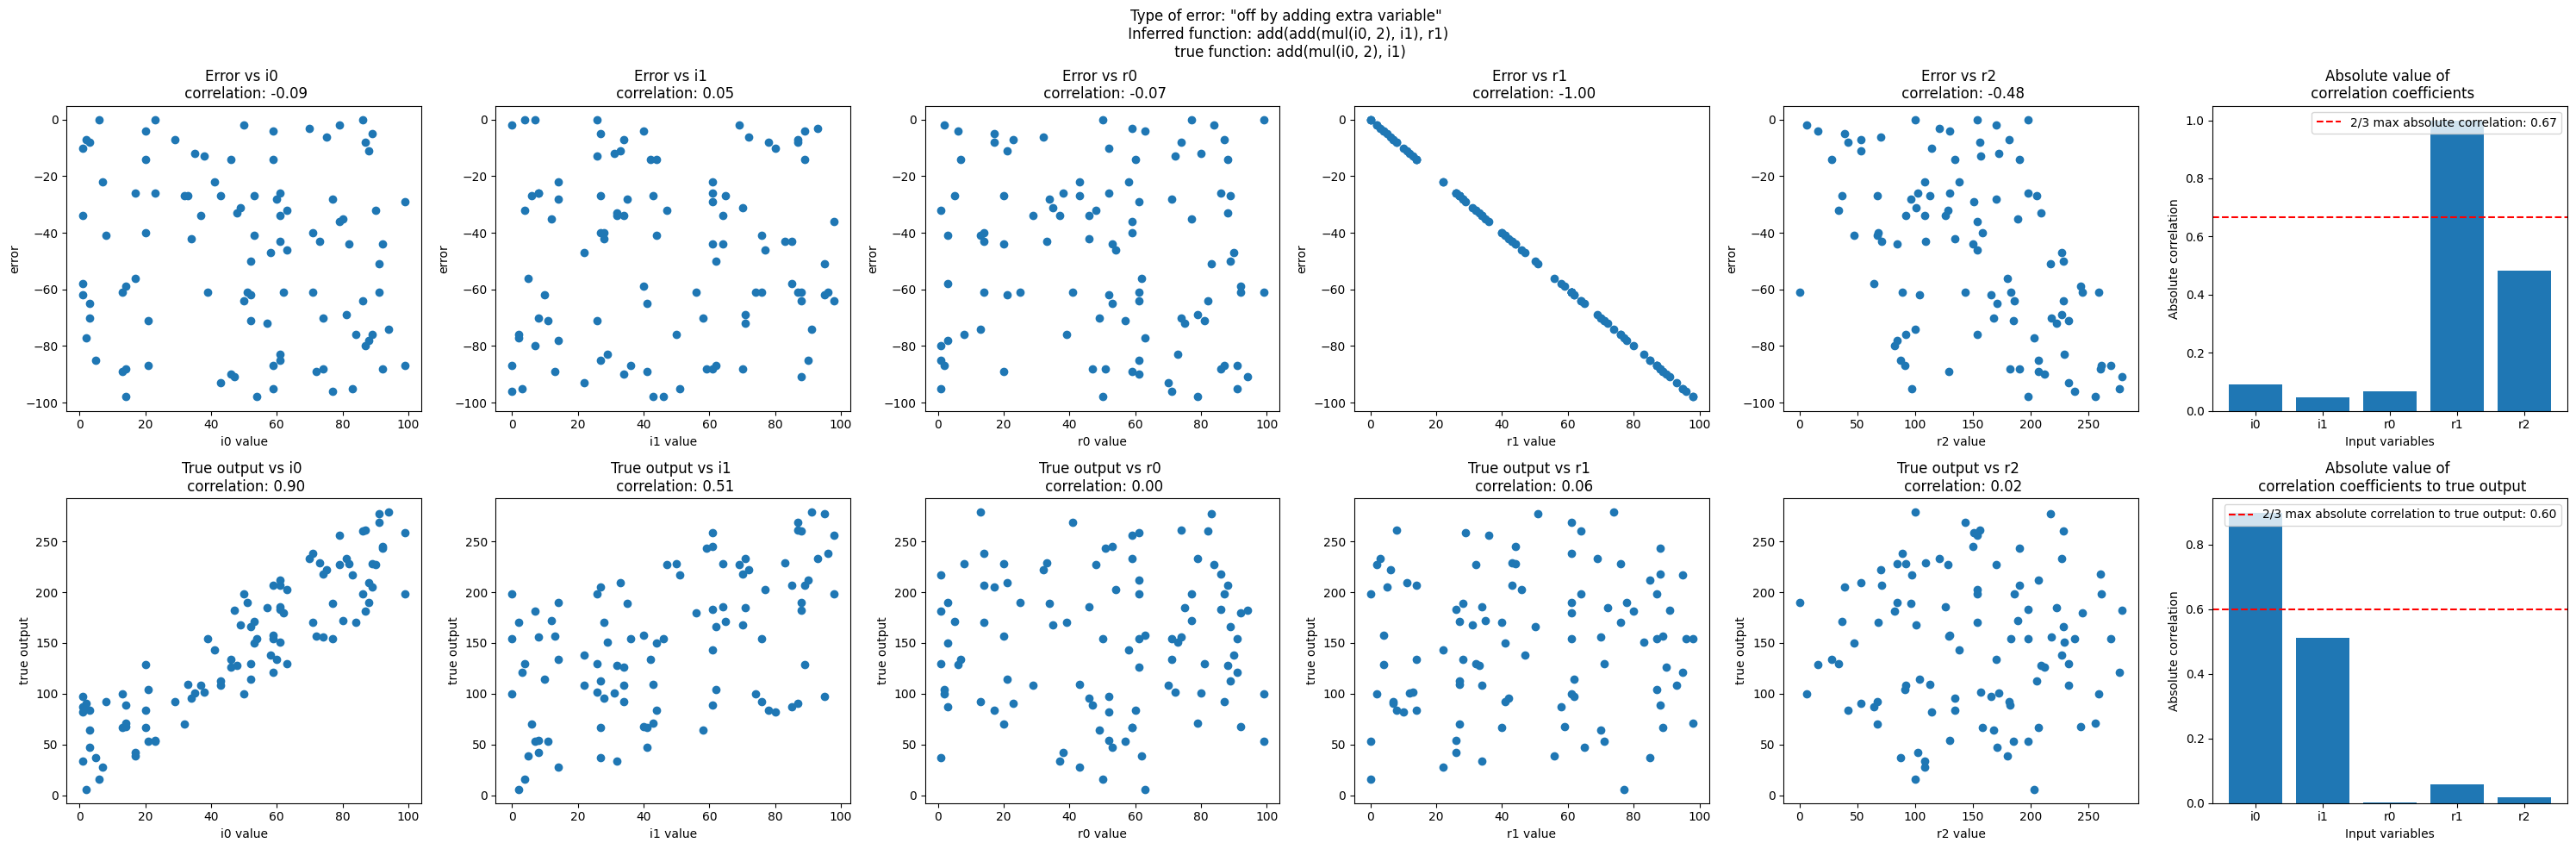

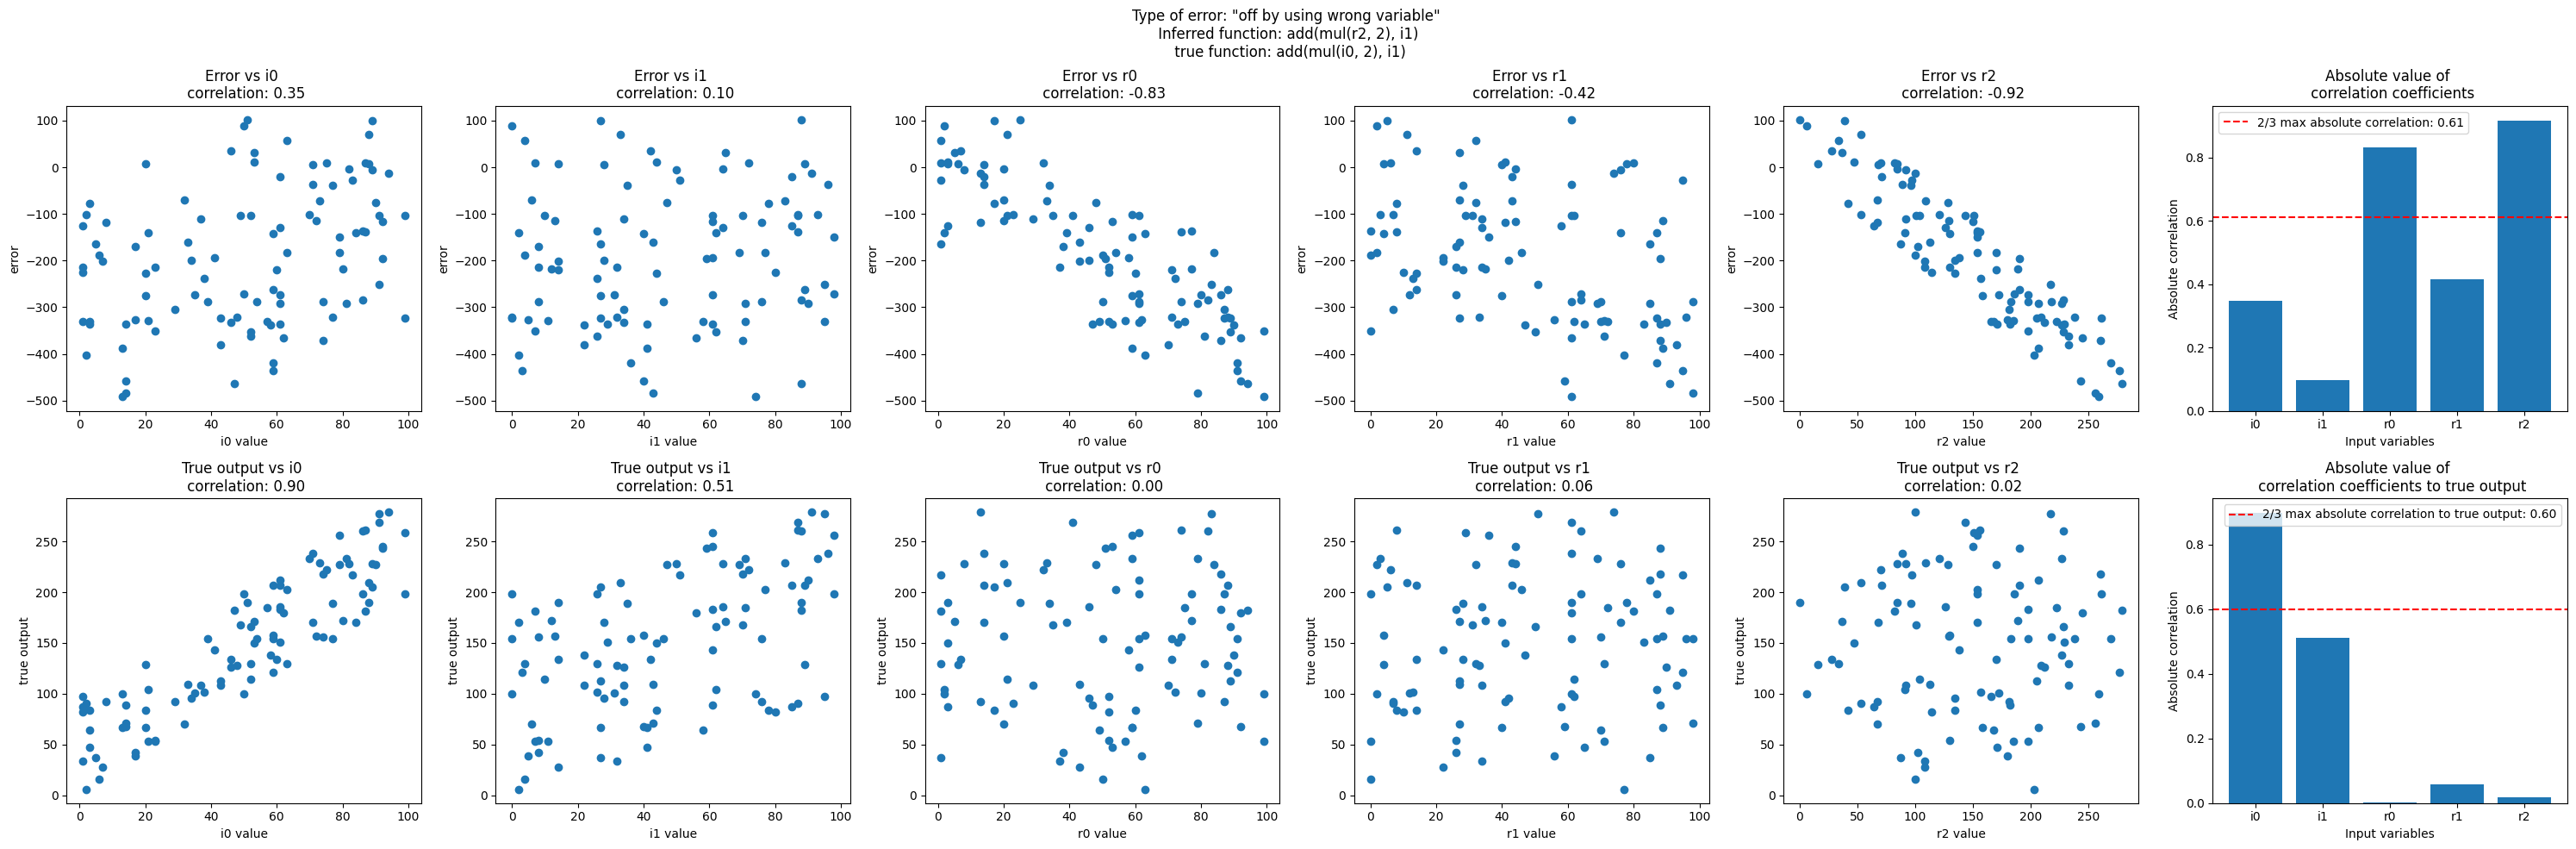

In [63]:
for func in fakeFunctions.keys():
    correlationCoefficients = []
    corrToTrue = []
    trueOut = testdf['o'].values
    error =  trueOut - testOuts[fakeFunctions[func]]
    if np.all(error == error[0]):
        print(f'Inferred function {func} has constant error, skipping correlation analysis.')
    else:
        #plots = len(testdf.columns) + len(testdf.drop(columns=['o']).columns) // 2
        plots = len(testdf.columns) 
        fig, axes = plt.subplots(2, plots, figsize=(5*len(testdf.columns), 10))
        if len(testdf.drop(columns=['o']).columns) == 1:
            axes = [axes]
        j = 0
        for i, col in enumerate(testdf.drop(columns=['o']).columns):
            if col.startswith('i'):
                axes[0,j].scatter(testdf[col].values, error)
                corr = np.corrcoef(testdf[col].values, error)[0,1]
                correlationCoefficients.append(abs(corr))
                axes[0,j].set_title(f'Error vs {col} \n correlation: {corr:.2f}')
                axes[0,j].set_xlabel(f'{col} value')
                axes[0,j].set_ylabel('error')
                # print(f'R2 of linear regression of error on {col}: {r_squared(error, testdf[col].values)}')

                tcorr = np.corrcoef(testdf[col].values, trueOut)[0,1]
                axes[1,j].scatter(testdf[col].values, trueOut)
                axes[1,j].set_title(f'True output vs {col} \n correlation: {tcorr:.2f}')
                axes[1,j].set_xlabel(f'{col} value')
                axes[1,j].set_ylabel('true output')
                corrToTrue.append(abs(tcorr))
                # axes[2,j].scatter(testdf[col].values, testOuts[fakeFunctions[func]])
                # corr = np.corrcoef(testdf[col].values, testOuts[fakeFunctions[func]])[0,1]
                # axes[2,j].set_title(f'Inferred output vs {col} \n correlation: {corr:.2f}')
                # axes[2,j].set_xlabel(f'{col} value')
                # axes[2,j].set_ylabel('inferred output')
                # check 1-step autocorrelation of error with this register variable
                # j += 1
                # lagRes = error[1:]
                # lagCol = testdf[col].values[:-1]
                # axes[0,j].scatter(lagCol, lagRes)
                # lagError = np.corrcoef(lagCol, lagRes)[0,1]
                # print(f'1-step autocorrelation of error with {col}: {lagError}')
                # print(f'R2 of linear regression of 1-step lagged error on {col}: {r_squared(lagRes, lagCol)}')
                # axes[0,j].set_title(f'1-step Autocorrelation of error with {col} \n correlation: {lagError:.2f}')
                # axes[0,j].set_xlabel(f'{col} value')
                # axes[0,j].set_ylabel('error')
                j+= 1
            else:
                axes[0,j].scatter(testdf[col].values, error)
                corr = np.corrcoef(testdf[col].values, error)[0,1]
                correlationCoefficients.append(abs(corr))
                # print(f'R2 of linear regression of error on {col}: {r_squared(error, testdf[col].values)}')
                axes[0,j].set_title(f'Error vs {col} \n correlation: {corr:.2f}')
                axes[0,j].set_xlabel(f'{col} value')
                axes[0,j].set_ylabel('error')
                tcorr = np.corrcoef(testdf[col].values, trueOut)[0,1]
                axes[1,j].scatter(testdf[col].values, trueOut)
                axes[1,j].set_title(f'True output vs {col} \n correlation: {tcorr:.2f}')
                axes[1,j].set_xlabel(f'{col} value')
                axes[1,j].set_ylabel('true output')
                corrToTrue.append(abs(tcorr))
                # axes[2,j].scatter(testdf[col].values, testOuts[fakeFunctions[func]])
                # corr = np.corrcoef(testdf[col].values, testOuts[fakeFunctions[func]])[0,1]
                # axes[2,j].set_title(f'Inferred output vs {col} \n correlation: {corr:.2f}')
                # axes[2,j].set_xlabel(f'{col} value')
                # axes[2,j].set_ylabel('inferred output')
                j += 1
        # print(j)
        halfmax = max(correlationCoefficients) * 2 / 3
        axes[0,-1].axhline(halfmax, color='red', linestyle='--', label=f'2/3 max absolute correlation: {halfmax:.2f}')
        axes[0,-1].bar(testdf.drop(columns=['o']).columns, correlationCoefficients) 
        axes[0,-1].set_title('Absolute value of \n correlation coefficients')
        axes[0,-1].set_xlabel('Input variables')
        axes[0,-1].set_ylabel('Absolute correlation')
        axes[0,-1].legend()
        halfmaxTrue = max(corrToTrue) * 2 / 3
        axes[1,-1].axhline(halfmaxTrue, color='red', linestyle='--', label=f'2/3 max absolute correlation to true output: {halfmaxTrue:.2f}')
        axes[1,-1].bar(testdf.drop(columns=['o']).columns, corrToTrue)
        axes[1,-1].set_title('Absolute value of \n correlation coefficients to true output')
        axes[1,-1].set_xlabel('Input variables')
        axes[1,-1].set_ylabel('Absolute correlation')
        axes[1,-1].legend()
        fig.suptitle(f'Type of error: "{func}" \n Inferred function: {fakeFunctions[func]} \n true function: {trueFunction}')
        plt.tight_layout()
        plt.show()

### True vs inferred output for each function.

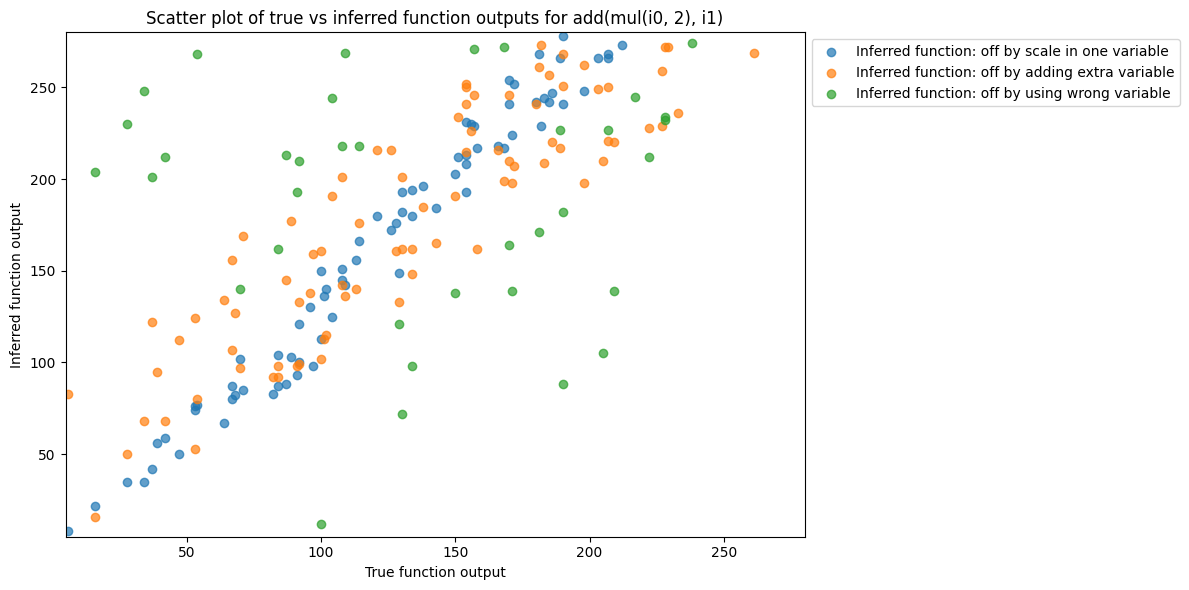

In [64]:
plt.figure(figsize=(12, 6))
for func in fakeFunctions.keys():
    plt.scatter(trueOut, testOuts[fakeFunctions[func]], label=f'Inferred function: {func}', alpha=0.7)
plt.xlabel('True function output')
plt.ylabel('Inferred function output')
plt.xlim(trueOut.min() - 1, trueOut.max() + 1)
plt.ylim(trueOut.min() - 1, trueOut.max() + 1)
plt.title(f'Scatter plot of true vs inferred function outputs for {trueFunction}')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

### Residuals displayed as a timeline for each intentionally incorrect function. 

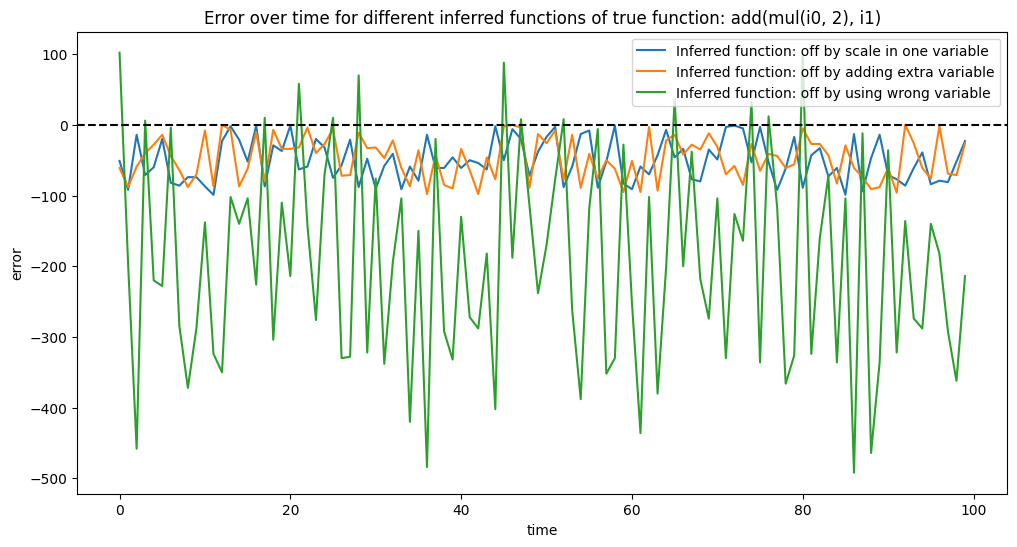

In [65]:
#residual error for each fake function over time
plt.figure(figsize=(12, 6))
for func in fakeFunctions.keys():
    error = trueOut - testOuts[fakeFunctions[func]]
    plt.plot(np.arange(max_table_length), error, label=f'Inferred function: {func}')
plt.axhline(0, color='black', linestyle='--')
plt.title(f'Error over time for different inferred functions of true function: {trueFunction}')
plt.xlabel('time')
plt.ylabel('error')
plt.legend()



### True function and intentionally incorrect functions tisplayed a sa time line.

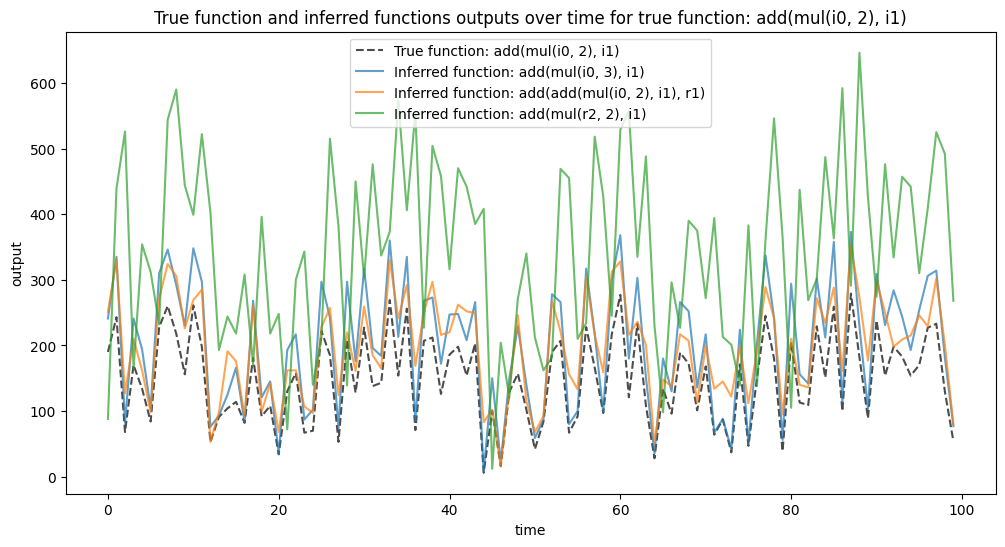

In [71]:
plt.figure(figsize=(12, 6))

plt.plot(np.arange(max_table_length), trueOut, label=f'True function: {trueFunction}', alpha=0.7, linestyle='dashed', color='black')
for i, func in enumerate(fakeFunctions.values()):
    plt.plot(np.arange(max_table_length), testOuts[func], label=f'Inferred function: {func}', alpha=0.7)

plt.title(f'True function and inferred functions outputs over time for true function: {trueFunction}')
plt.xlabel('time')
plt.ylabel('output')
plt.legend()    
plt.show()

### Histogram of normalized errors for each intentionally incorrect function

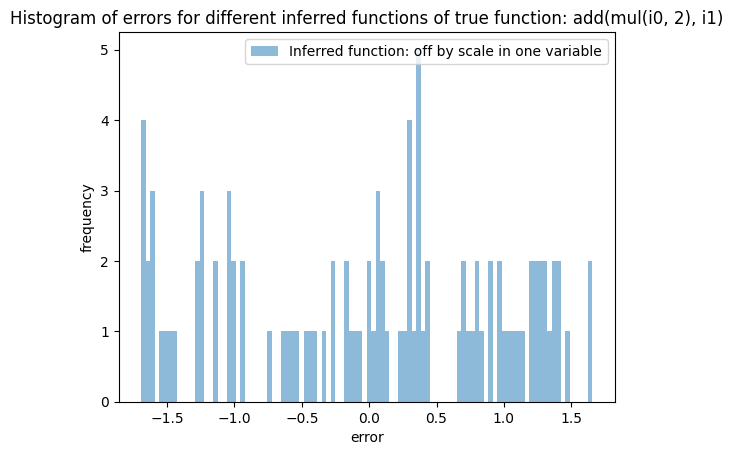

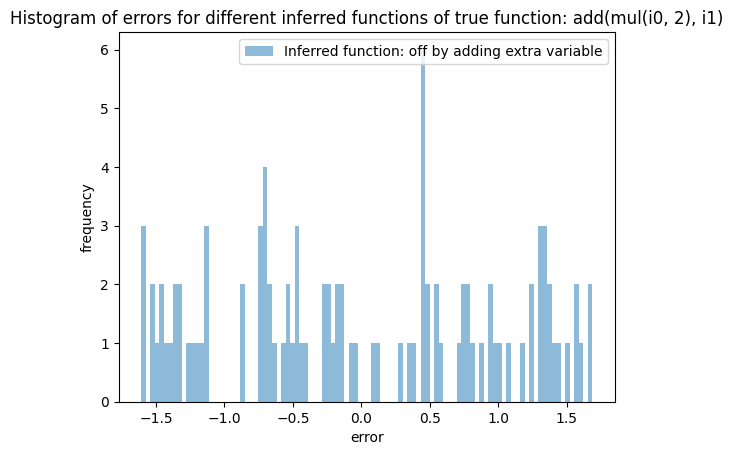

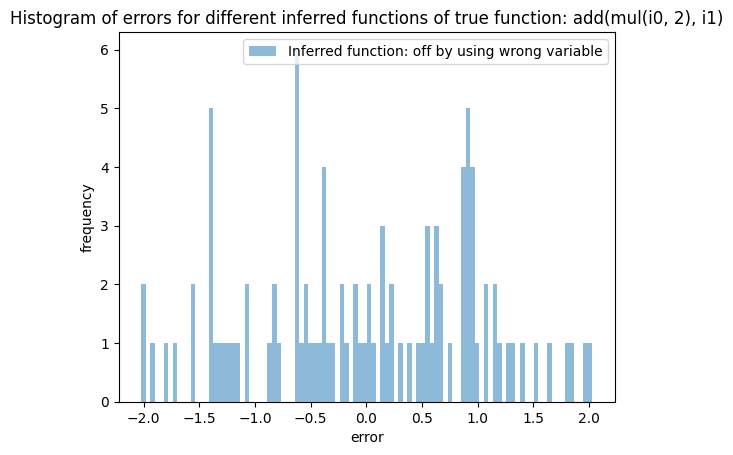

In [72]:

for func in fakeFunctions.keys():
    error = testOuts[fakeFunctions[func]] - trueOut
    error = error - np.mean(error)
    if np.std(error) != 0:
        error = error / np.std(error)
        plt.hist(error, bins=100, alpha=0.5, label=f'Inferred function: {func}')
        plt.title(f'Histogram of errors for different inferred functions of true function: {trueFunction}')
        plt.xlabel('error')
        plt.ylabel('frequency')
        plt.legend()
        plt.show()
